# Generation 1 Experiment Results

This notebook summarizes and visualizes the results from the Generation 1 counterfactual experiments, comparing different explainers, models, and the effect of constraints on counterfactual validity, feasibility, and computation time.

------

The first phase followed a 2×2×2 design in which two explainers, two prediction models, and two settings (with and without permitted_ranges) were combined. The purpose was to identify key patterns, limitations, and sensitivities in the counterfactual generation process.

In this phase, baseline models with standard parameters (300 trees) were used together with the following DiCE settings:
- total_CFs = 10
- stopping_threshold = 0.9
- posthoc_sparsity_param = 0.1
- maxiterations (genetic) = 500
- Permitted_ranges 

The Generation 1 experiments reveal clear differences between explainers, models, and the use of constraints. Random search showed the greatest variation and often produced implausible counterfactuals without constraints, especially with Random Forest. XGBoost was more stable in random search and achieved high validity in both settings, but still struggled with feasibility when constraints were absent. The genetic algorithm was consistently faster and more robust than random search, with short runtimes and high validity when constraints were applied. Without constraints, there were cases where validity was not achieved or changes were marginal. In summary, the results show that constraints are crucial for plausible counterfactuals, random search is sensitive to model choice and parameter settings, and the genetic algorithm is the most efficient and stable method given the data for this experiment. 

---

Table 3.3: Summary of Results – Generation 1  
--------------------------------------------------
| Explainer      | Model | Constraints | Validity | Feasibility | Time (s) | Comment                                                      |
|----------------|-------|-------------|----------|-------------|----------|--------------------------------------------------------------|
| random-search  | RF    | Yes         | Medium   | High        | 1028     | More stable but slow; some validity failures                 |
| random-search  | RF    | No          | Low      | Low         | 301      | Several implausible CFs; validity sometimes fails            |
| random-search  | XGB   | Yes         | High     | High        | 435      | Robust; mainly BMI adjustments                               |
| random-search  | XGB   | No          | High     | Medium      | 134      | Valid but often implausible CFs                              |
| genetic        | RF    | Yes         | High     | High        | 19       | Fast and stable; varied solutions                            |
| genetic        | RF    | No          | Medium   | Low         | 19       | Some validity failures; some implausible CFs                 |
| genetic        | XGB   | Yes         | Medium/High | High     | 9        | Fastest; one observation without validity                    |
| genetic        | XGB   | No          | Medium/Low | Low       | 11       | Marginal BMI changes insufficient for validity               |

In [10]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [12]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "gen1_fixed.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [13]:
df = pd.read_csv(RESULTS_CSV_PATH)
df

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before_%,avg_risk_after_%,min_risk_after_%,risk_reduction_%,avg_gen_time_sec,top_features,csv_path
0,RF_highthres_2026-04-21,genetic,RandomForest,False,10,1000,0.9,9,85,31,36.5%,88.9%,3.77,3.52,NaN,11.0,3.8,0.0,76.5,2.10,bmi: 100% | etfruit: 55% | eatveg: 52% | ...,/home/dyretna/Dokument/Code/GitHub/nightingale...
1,RF_lowthres_2026-04-21,genetic,RandomForest,False,10,1000,0.1,9,61,38,62.3%,100.0%,3.79,3.44,NaN,11.0,1.8,0.0,80.0,2.05,bmi: 100% | etfruit: 61% | cgtsmok: 50% |...,/home/dyretna/Dokument/Code/GitHub/nightingale...
2,RF_prange_highthres_2026-04-29,genetic,RandomForest,True,10,1000,0.9,9,83,38,45.8%,100.0%,2.50,2.29,NaN,11.0,3.0,0.0,78.7,2.09,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,/home/dyretna/Dokument/Code/GitHub/nightingale...
3,RF_prange_lowthres_2026-04-21,genetic,RandomForest,True,20,1000,0.1,9,129,77,59.7%,100.0%,2.58,2.41,NaN,11.0,3.0,0.0,76.2,2.66,bmi: 100% | slprl: 36% | alcfreq: 34% | ...,/home/dyretna/Dokument/Code/GitHub/nightingale...
4,XGB_highthres_2026-04-17,genetic,XGBoost,False,10,500,0.9,9,86,38,44.2%,77.8%,3.74,3.52,NaN,10.2,2.6,0.2,77.9,1.18,bmi: 100% | etfruit: 63% | cgtsmok: 47% |...,/home/dyretna/Dokument/Code/GitHub/nightingale...
5,XGB_prange_highthres_2026-04-17,genetic,XGBoost,True,10,500,0.9,9,84,43,51.2%,88.9%,2.49,2.23,NaN,10.2,3.0,0.0,76.7,0.99,bmi: 100% | alcfreq: 33% | etfruit: 28% |...,/home/dyretna/Dokument/Code/GitHub/nightingale...
6,XGB_prange_lowthres_2026-04-17,genetic,XGBoost,True,20,1000,0.1,9,133,73,54.9%,100.0%,2.49,2.25,NaN,10.2,2.2,0.0,79.5,1.83,bmi: 100% | etfruit: 37% | alcfreq: 29% |...,/home/dyretna/Dokument/Code/GitHub/nightingale...
7,RF_highthres_2026-04-21,random,RandomForest,False,10,1000,0.9,9,90,22,24.4%,88.9%,1.82,1.76,NaN,11.0,4.8,0.0,70.7,33.46,alcfreq: 41% | bmi: 32% | dosprt: 27% | ...,/home/dyretna/Dokument/Code/GitHub/nightingale...
8,RF_lowthres_2026-04-21,random,RandomForest,False,10,1000,0.1,9,90,40,44.4%,100.0%,1.82,1.71,NaN,11.0,3.8,0.0,74.3,33.29,bmi: 38% | dosprt: 38% | eatveg: 28% | e...,/home/dyretna/Dokument/Code/GitHub/nightingale...
9,RF_prange_highthres_2026-04-29,random,RandomForest,True,10,1000,0.9,9,90,22,24.4%,66.7%,1.45,1.48,NaN,11.0,3.2,0.0,76.5,114.28,bmi: 64% | dosprt: 27% | alcfreq: 18% | ...,/home/dyretna/Dokument/Code/GitHub/nightingale...


In [14]:
# Melt for grouped barplot
df_melt = df.melt(id_vars=["Explainer", "Model", "Constraints"], value_vars=["Validity", "Feasibility"],
                  var_name="Metric", value_name="Score")

df_melt

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Explainer', 'Model', 'Constraints', 'Validity', 'Feasibility']"

/tmp/ipykernel_25007/2937514501.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


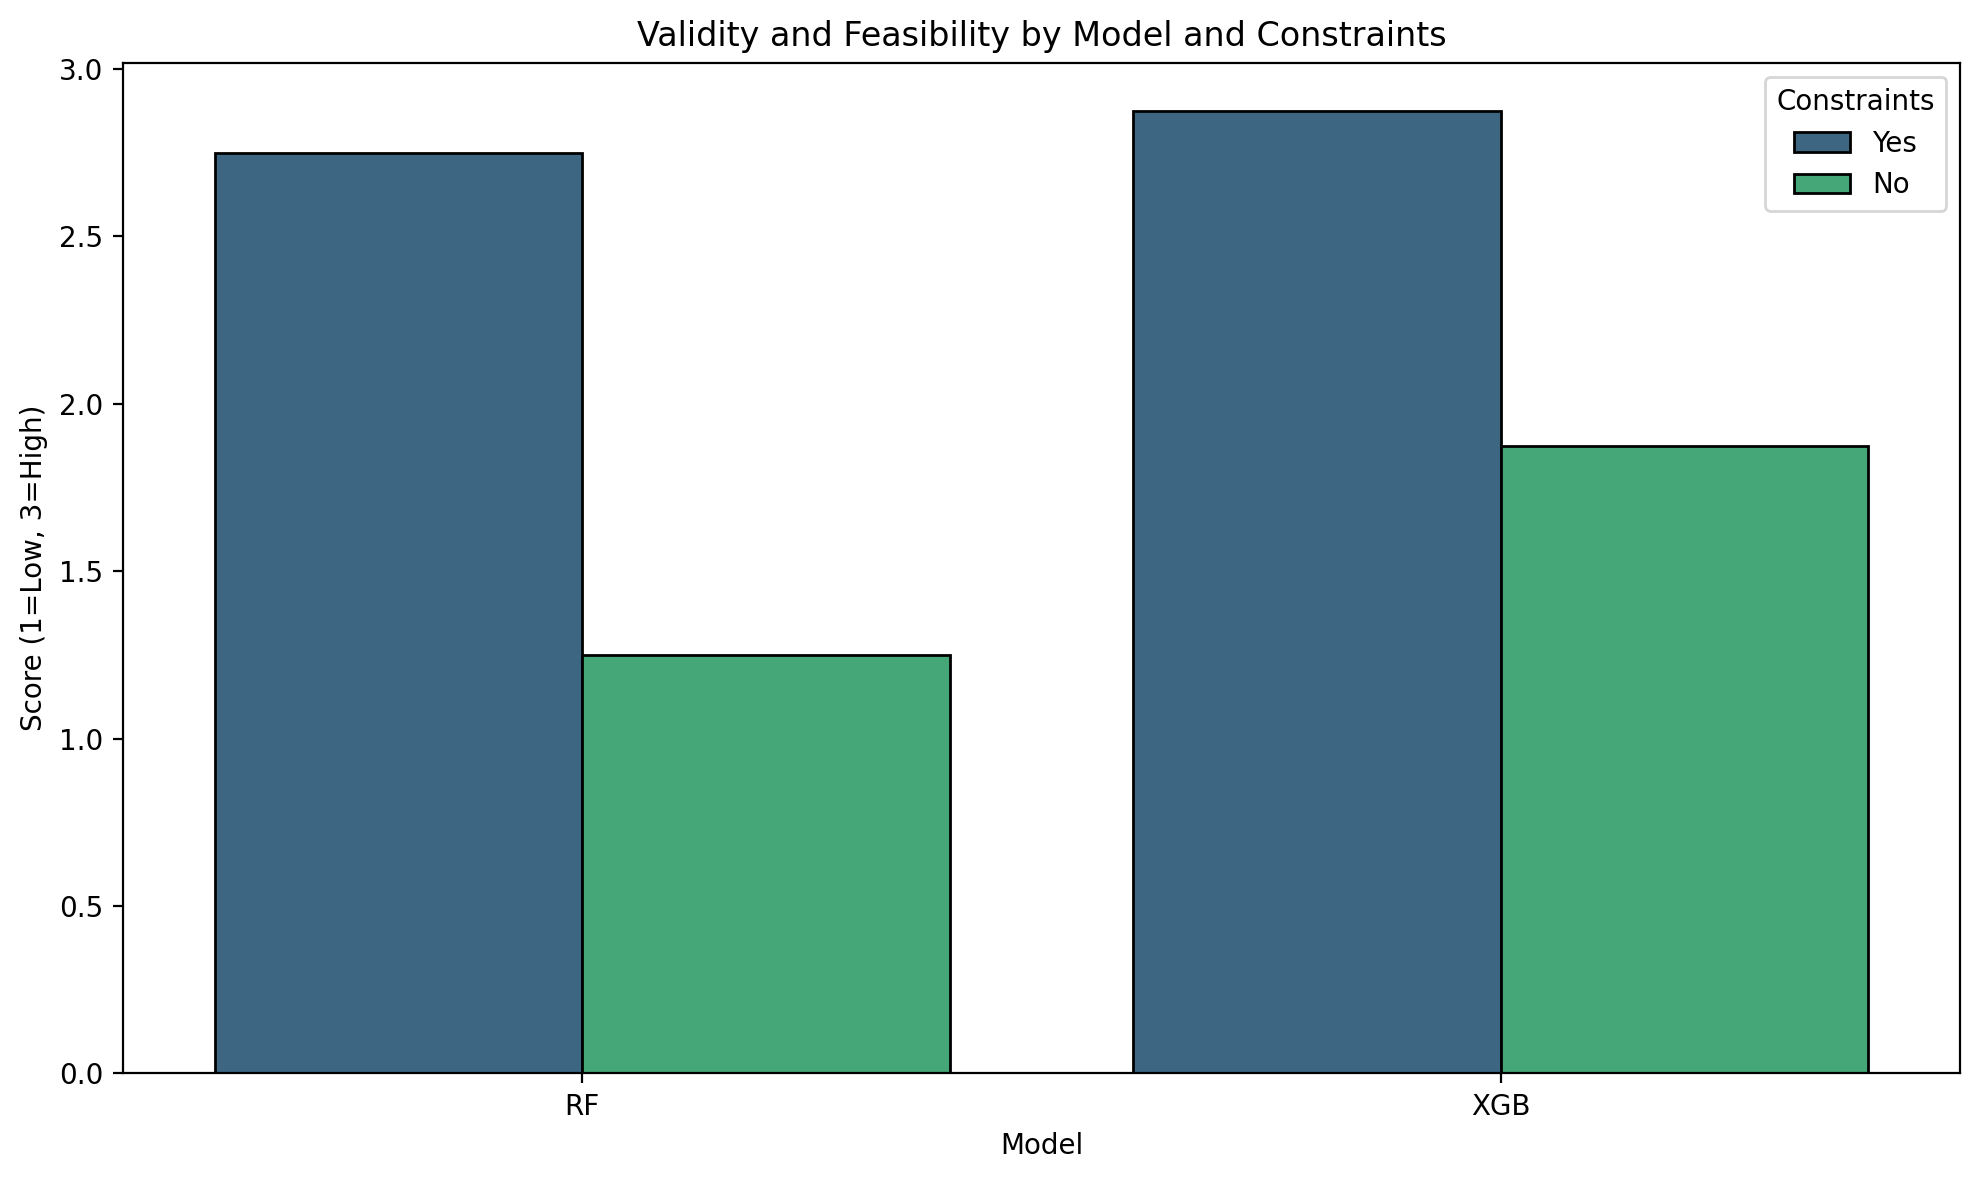

In [ ]:
plt.figure(figsize=(10,6), dpi=200)
sns.barplot(
    data=df_melt,
    x="Model",
    y="Score",
    hue="Constraints",
    palette="viridis",
    ci=None,
    dodge=True,
    hue_order=["Yes", "No"],
    edgecolor="black",
    capsize=0.1,
    errorbar=None
)
plt.title("Validity and Feasibility by Model and Constraints")
plt.ylabel("Score (1=Low, 3=High)")
plt.xlabel("Model")
plt.legend(title="Constraints")
plt.tight_layout()
plt.show()

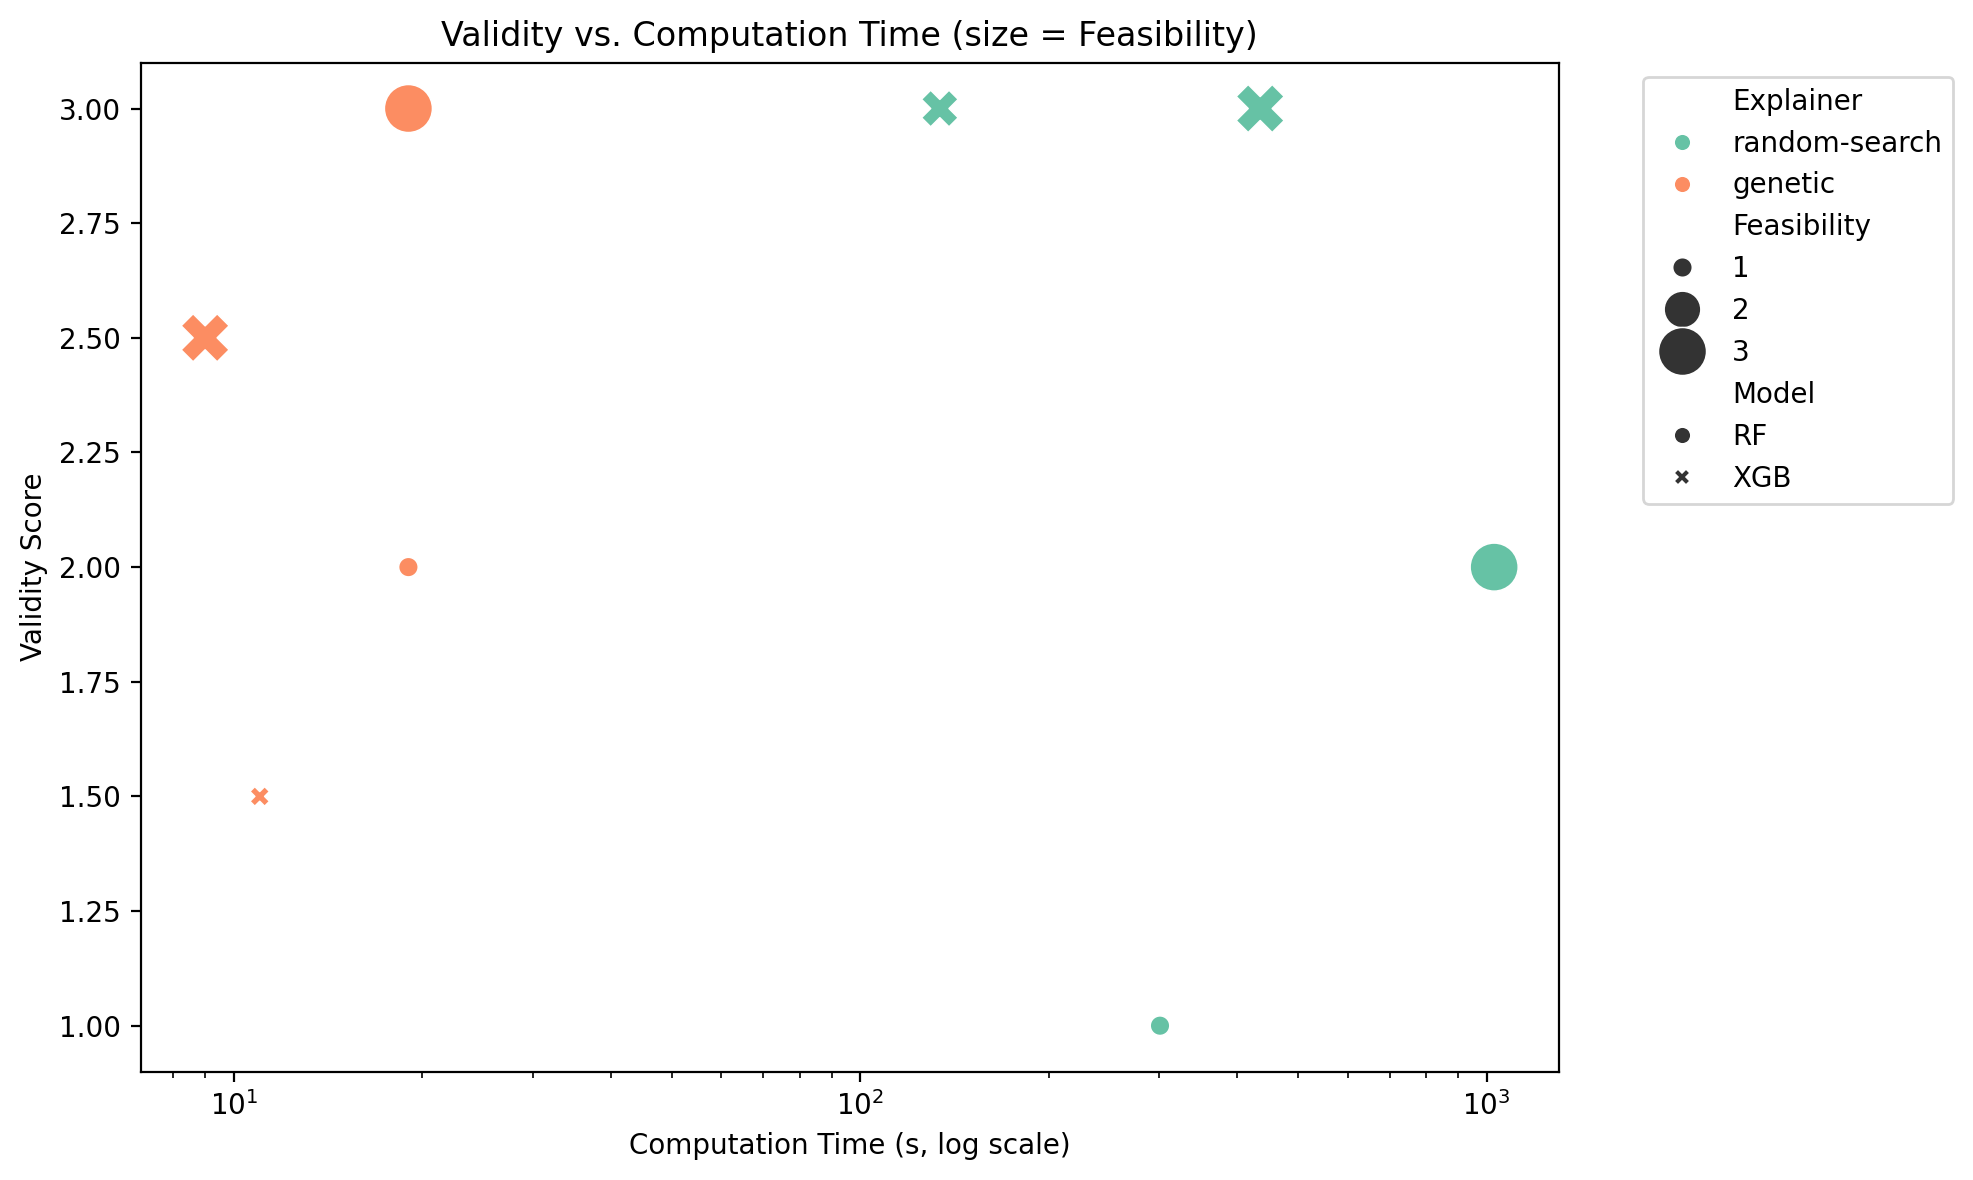

In [ ]:
plt.figure(figsize=(10,6), dpi=200)
sns.scatterplot(
    data=df,
    x="Time",
    y="Validity",
    hue="Explainer",
    style="Model",
    size="Feasibility",
    sizes=(50, 300),
    palette="Set2"
)
plt.xscale("log")
plt.xlabel("Computation Time (s, log scale)")
plt.ylabel("Validity Score")
plt.title("Validity vs. Computation Time (size = Feasibility)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## sns examples

### stacked histogram

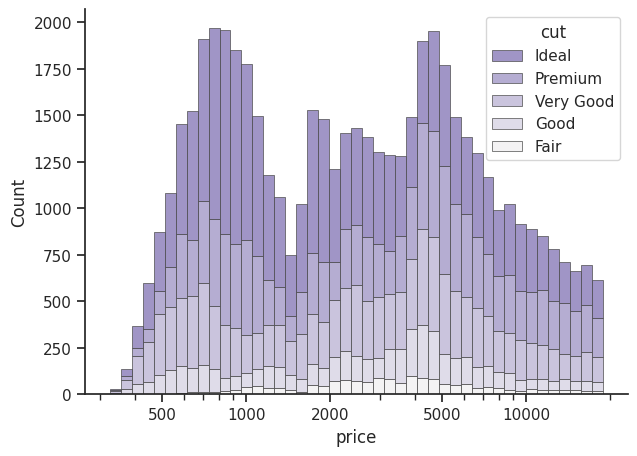

In [ ]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

diamonds = sns.load_dataset("diamonds")

f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    diamonds,
    x="price", hue="cut",
    multiple="stack",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
    log_scale=True,
)
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([500, 1000, 2000, 5000, 10000])

### facet grid

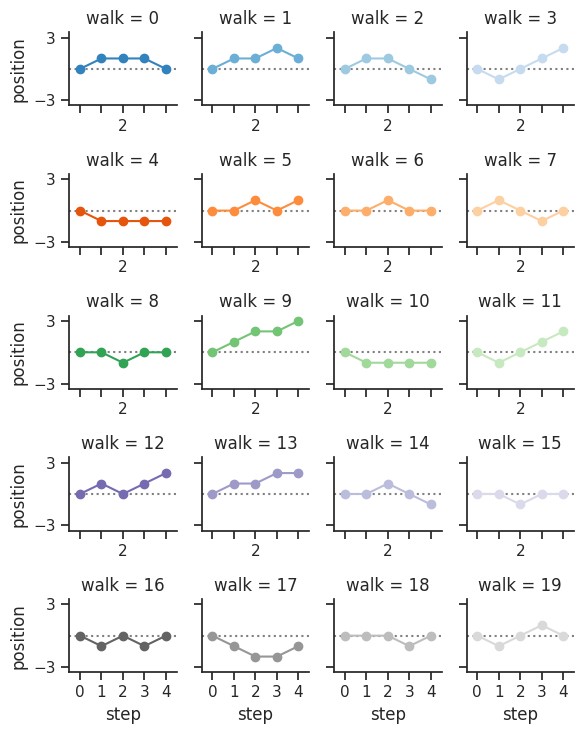

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Create a dataset with many short random walks
rs = np.random.RandomState(4)
pos = rs.randint(-1, 2, (20, 5)).cumsum(axis=1)
pos -= pos[:, 0, np.newaxis]
step = np.tile(range(5), 20)
walk = np.repeat(range(20), 5)
df = pd.DataFrame(np.c_[pos.flat, step, walk],
                  columns=["position", "step", "walk"])

# Initialize a grid of plots with an Axes for each walk
grid = sns.FacetGrid(df, col="walk", hue="walk", palette="tab20c",
                     col_wrap=4, height=1.5)

# Draw a horizontal line to show the starting point
grid.refline(y=0, linestyle=":")

# Draw a line plot to show the trajectory of each random walk
grid.map(plt.plot, "step", "position", marker="o")

# Adjust the tick positions and labels
grid.set(xticks=np.arange(5), yticks=[-3, 3],
         xlim=(-.5, 4.5), ylim=(-3.5, 3.5))

# Adjust the arrangement of the plots
grid.fig.tight_layout(w_pad=1)